In [1]:

import numpy as np
import pandas as pd
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyhepmc
import itertools
import math


# Line styles
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.antialiased'] = True
mpl.rcParams['lines.dashed_pattern'] = 2.8, 1.5
mpl.rcParams['lines.dashdot_pattern'] = 4.8, 1.5, 0.8, 1.5
mpl.rcParams['lines.dotted_pattern'] = 1.1, 1.1
mpl.rcParams['lines.scale_dashes'] = True

# Default colors
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler('color',['cornflowerblue','forestgreen','maroon','goldenrod','firebrick','mediumorchid', 'navy', 'brown'])

# Fonts
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'CMU Serif'
mpl.rcParams['font.sans-serif'] = 'CMU Sans Serif, DejaVu Sans, Bitstream Vera Sans, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif'
mpl.rcParams['text.usetex'] = True

# Axes
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.labelpad'] = 9.0
                                                  
                                                  
# Tick marks - the essence of life
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['xtick.minor.width'] = 0.75
mpl.rcParams['xtick.major.pad'] = 8
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 2.5
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['ytick.minor.width'] = 0.75
mpl.rcParams['ytick.major.pad'] = 8
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.minor.visible'] = True

# Legend
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 1.
#mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.borderpad'] = 0.4 # border whitespace
mpl.rcParams['legend.labelspacing'] = 0.5 # the vertical space between the legend entries
mpl.rcParams['legend.handlelength'] = 1.5 # the length of the legend lines
mpl.rcParams['legend.handleheight'] = 0.7 # the height of the legend handle
mpl.rcParams['legend.handletextpad'] = 0.5 # the space between the legend line and legend text
mpl.rcParams['legend.borderaxespad'] = 0.5 # the border between the axes and legend edge
mpl.rcParams['legend.columnspacing'] = 2.0 # column separation


# Figure size
mpl.rcParams['figure.figsize'] = 12, 6
mpl.rcParams['figure.dpi'] = 200

# Save details
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.1

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

def fix_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    
    return ax

In [35]:
def classify_isospin(isop1,isop2):
    if(isop1 == 2212 and isop2 == 2212):
        return 'pp'
    elif(isop1 == 2112 and isop2 == 2112):
        return 'nn'
    else:
        return 'np'

def get_double_diff_xsec_wgt(file, angle, delta, mybins_omega):

    emin = 2*np.sqrt(225**2 + 938**2)

    mn = 938.5

    mybins2 = np.linspace(-1.,1.,len(mybins_omega))
    mybins_leadingmom = np.linspace(225.,1500.,len(mybins_omega))
    mybins_totalE = np.linspace(emin,3000,len(mybins_omega))
    momentum_bins = np.linspace(225,1200,30)
    emiss_bins = np.linspace(0,300,60)
    init_momentum_bins = np.linspace(0,600,16)
    init_momentum_bins_more = np.linspace(0,600,30)
    Q2_bins = np.linspace(0,1.4,30)
    EQE_bins = np.linspace(0,1.4,30)
    
    omega_nn = np.zeros(len(mybins_omega)-1)
    omega_np = np.zeros(len(mybins_omega)-1)
    omega_pp = np.zeros(len(mybins_omega)-1)
    omega_nuc = np.zeros(len(mybins_omega)-1)
    Q2_nuc = np.zeros(len(Q2_bins)-1)
    EQE_nuc = np.zeros(len(EQE_bins)-1)

    leading_nmom_nn = np.zeros(len(mybins_leadingmom)-1)
    leading_nmom_np = np.zeros(len(mybins_leadingmom)-1)
    leading_mom_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_submom_hist = np.zeros(len(mybins_leadingmom)-1)

    leading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    leading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    
    cos12_nn = np.zeros(len(mybins2)-1)
    cos12_np = np.zeros(len(mybins2)-1) 

    cospp1_hist = np.zeros(len(mybins2)-1)
    cospp2_hist = np.zeros(len(mybins2)-1)

    E_total_nn = np.zeros(len(mybins_totalE) -1)
    E_total_np = np.zeros(len(mybins_totalE) -1)

    np_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
    nn_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))

    np_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))
    nn_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))

    Emiss_np = np.zeros((len(emiss_bins)-1))
    Emiss_nn = np.zeros((len(emiss_bins)-1))
    Emiss = np.zeros(len(emiss_bins)-1)

    ebind = 18.0
    
    xsec = 0
    sum_of_weights = 0

    num_nn = 0
    num_np = 0
    num_pp = 0
    other = 0
    total = 0

    high_cos = math.cos((angle + delta)*np.pi/180)
    low_cos = math.cos((angle - delta)*np.pi/180)
    delta_cos = (low_cos - high_cos)
    with open(file, 'r') as f:
        xsec = float(f.readline().strip())
        while True:
            block = list(itertools.islice(f,7))
            if not block:
                break
            probe = [float(x) for x in block[0].split()]
            lep = [float(x) for x in block[1].split()]
            nuc1 = [float(x) for x in block[2].split()]
            nucp1 = [float(x) for x in block[3].split()]
            nuc2 = [float(x) for x in block[4].split()]
            nucp2 = [float(x) for x in block[5].split()]
            wgt = float(block[6])

            isospin = classify_isospin(nuc1[4],nuc2[4])

            total+=1
            sum_of_weights += wgt
            
            omega = probe[0] - lep[0]   
            probe_3 = [probe[1], probe[2], probe[3]]
            probe_mom = np.sqrt(np.dot(probe_3,probe_3))
            lep_3 = [lep[1], lep[2], lep[3]]

            if(lep[0] < 400.):
                continue

            costhetal = np.dot(probe_3,lep_3)/lep[0]/probe[0]

            thetal = np.arccos(costhetal)*180/np.pi

            if (thetal < 15. or thetal > 45.):
                continue

            nuc1_3 = [nuc1[1],nuc1[2],nuc1[3]]
            nuc2_3 = [nuc2[1],nuc2[2],nuc2[3]]
            nucp1_3 = [nucp1[1],nucp1[2],nucp1[3]]
            nucp2_3 = [nucp2[1],nucp2[2],nucp2[3]]

            qvec = np.array(probe_3) - np.array(lep_3)
            qvecmag = np.sqrt(np.dot(qvec,qvec))

            Q2 = qvecmag**2 - omega**2

            Q2 *= 1e-6

            nuc1_mom = np.sqrt(np.dot(nuc1_3,nuc1_3))
            nuc2_mom = np.sqrt(np.dot(nuc2_3,nuc2_3))
            nucp1_mom = np.sqrt(np.dot(nucp1_3,nucp1_3))
            nucp2_mom = np.sqrt(np.dot(nucp2_3,nucp2_3))

            leading_mom = 0.
            subleading_mom = 0.
            totalE = nucp1[0] + nucp2[0]
            if(nucp1_mom > nucp2_mom):
                leading_mom = nucp1_mom
                subleading_mom = nucp2_mom
            else:
                leading_mom = nucp2_mom
                subleading_mom = nucp1_mom

            cospp1 = nucp1_3[2]/nucp1_mom
            cospp2 = nucp2_3[2]/nucp2_mom

            pp12cos = np.dot(nucp1_3,nucp2_3)/(nucp1_mom*nucp2_mom)

            EQE = (2.*mn*ebind + 2*mn*lep[0])/2./(mn - lep[0] + lep[0]*costhetal)/1e3


            if(nucp1[4] == 2212 and nucp2[4] == 2112):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            elif(nucp1[4] == 2112 and nucp2[4] == 2212):
                T2 = np.sqrt(mn**2 + nucp2_mom**2) - mn
                Em = omega - T2
            elif(nucp1[4] == 2212 and nucp2[4] == 2212):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            else:
                continue

            idx0 = np.searchsorted(mybins_omega, omega, side='left')
            if idx0 > len(mybins_omega)-1:
                continue

            idxmom = np.searchsorted(mybins_leadingmom,leading_mom,side='left')
            if idxmom > len(mybins_omega) -1:
                continue
                
            idxsubmom = np.searchsorted(mybins_leadingmom,subleading_mom,side='left')
            if idxsubmom > len(mybins_omega) -1:
                continue

            idxcos = np.searchsorted(mybins2,cospp1,side='left')
            if idxcos > len(mybins2) -1:
                continue
            idxcos2 = np.searchsorted(mybins2,cospp2,side='left')
            if idxcos2 > len(mybins2) -1:
                continue
            idxem = np.searchsorted(emiss_bins,Em, side='left')
            if idxem > len(emiss_bins) -1:
                continue

            idxQ2 = np.searchsorted(Q2_bins, Q2, side='left')
            if idxQ2 > len(Q2_bins) -1:
                continue

            idxEQE = np.searchsorted(EQE_bins, EQE, side='left')
            if idxEQE > len(EQE_bins) - 1:
                continue
                
            Q2_nuc[idxQ2-1] += wgt

            EQE_nuc[idxEQE-1] += wgt
                
            Emiss[idxem-1] += wgt
            cospp1_hist[idxcos-1] += wgt
            cospp2_hist[idxcos2-1] += wgt
            omega_nuc[idx0-1] += wgt 
            leading_mom_hist[idxmom-1] += wgt
            leading_submom_hist[idxsubmom-1] += wgt

            if(isospin == 'pp'):
                omega_nn[idx0-1] += wgt
                Emiss_nn[idxem-1] += wgt
            if(isospin == 'np' and nucp1[4] == 2212):
                omega_np[idx0-1] += wgt
                Emiss_np[idxem-1] += wgt

            
        omega_bin_width = 2*np.pi*np.diff(mybins_omega)
        omega_nuc *= xsec/omega_bin_width/sum_of_weights
        omega_nn *= xsec/omega_bin_width/sum_of_weights
        omega_np *= xsec/omega_bin_width/sum_of_weights
        leading_mom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        leading_submom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        cospp1_hist *= xsec/np.diff(mybins2)/sum_of_weights
        cospp2_hist *= xsec/np.diff(mybins2)/sum_of_weights
        Emiss_nn *= xsec/np.diff(emiss_bins)/sum_of_weights
        Emiss_np *= xsec/np.diff(emiss_bins)/sum_of_weights

        EQE_nuc *= xsec/np.diff(EQE_bins)/sum_of_weights

        Q2_nuc *= xsec/np.diff(Q2_bins)/sum_of_weights
    
    print('xsec = ',xsec)
    return Q2_nuc,leading_mom_hist,leading_submom_hist,cospp1_hist,cospp2_hist,Emiss_nn,Emiss_np,EQE_nuc

Text(0, 0.5, '$\\frac{d\\sigma}{dE_{QE}} (\\mu b \\,\\rm{GeV}^{-1})$')

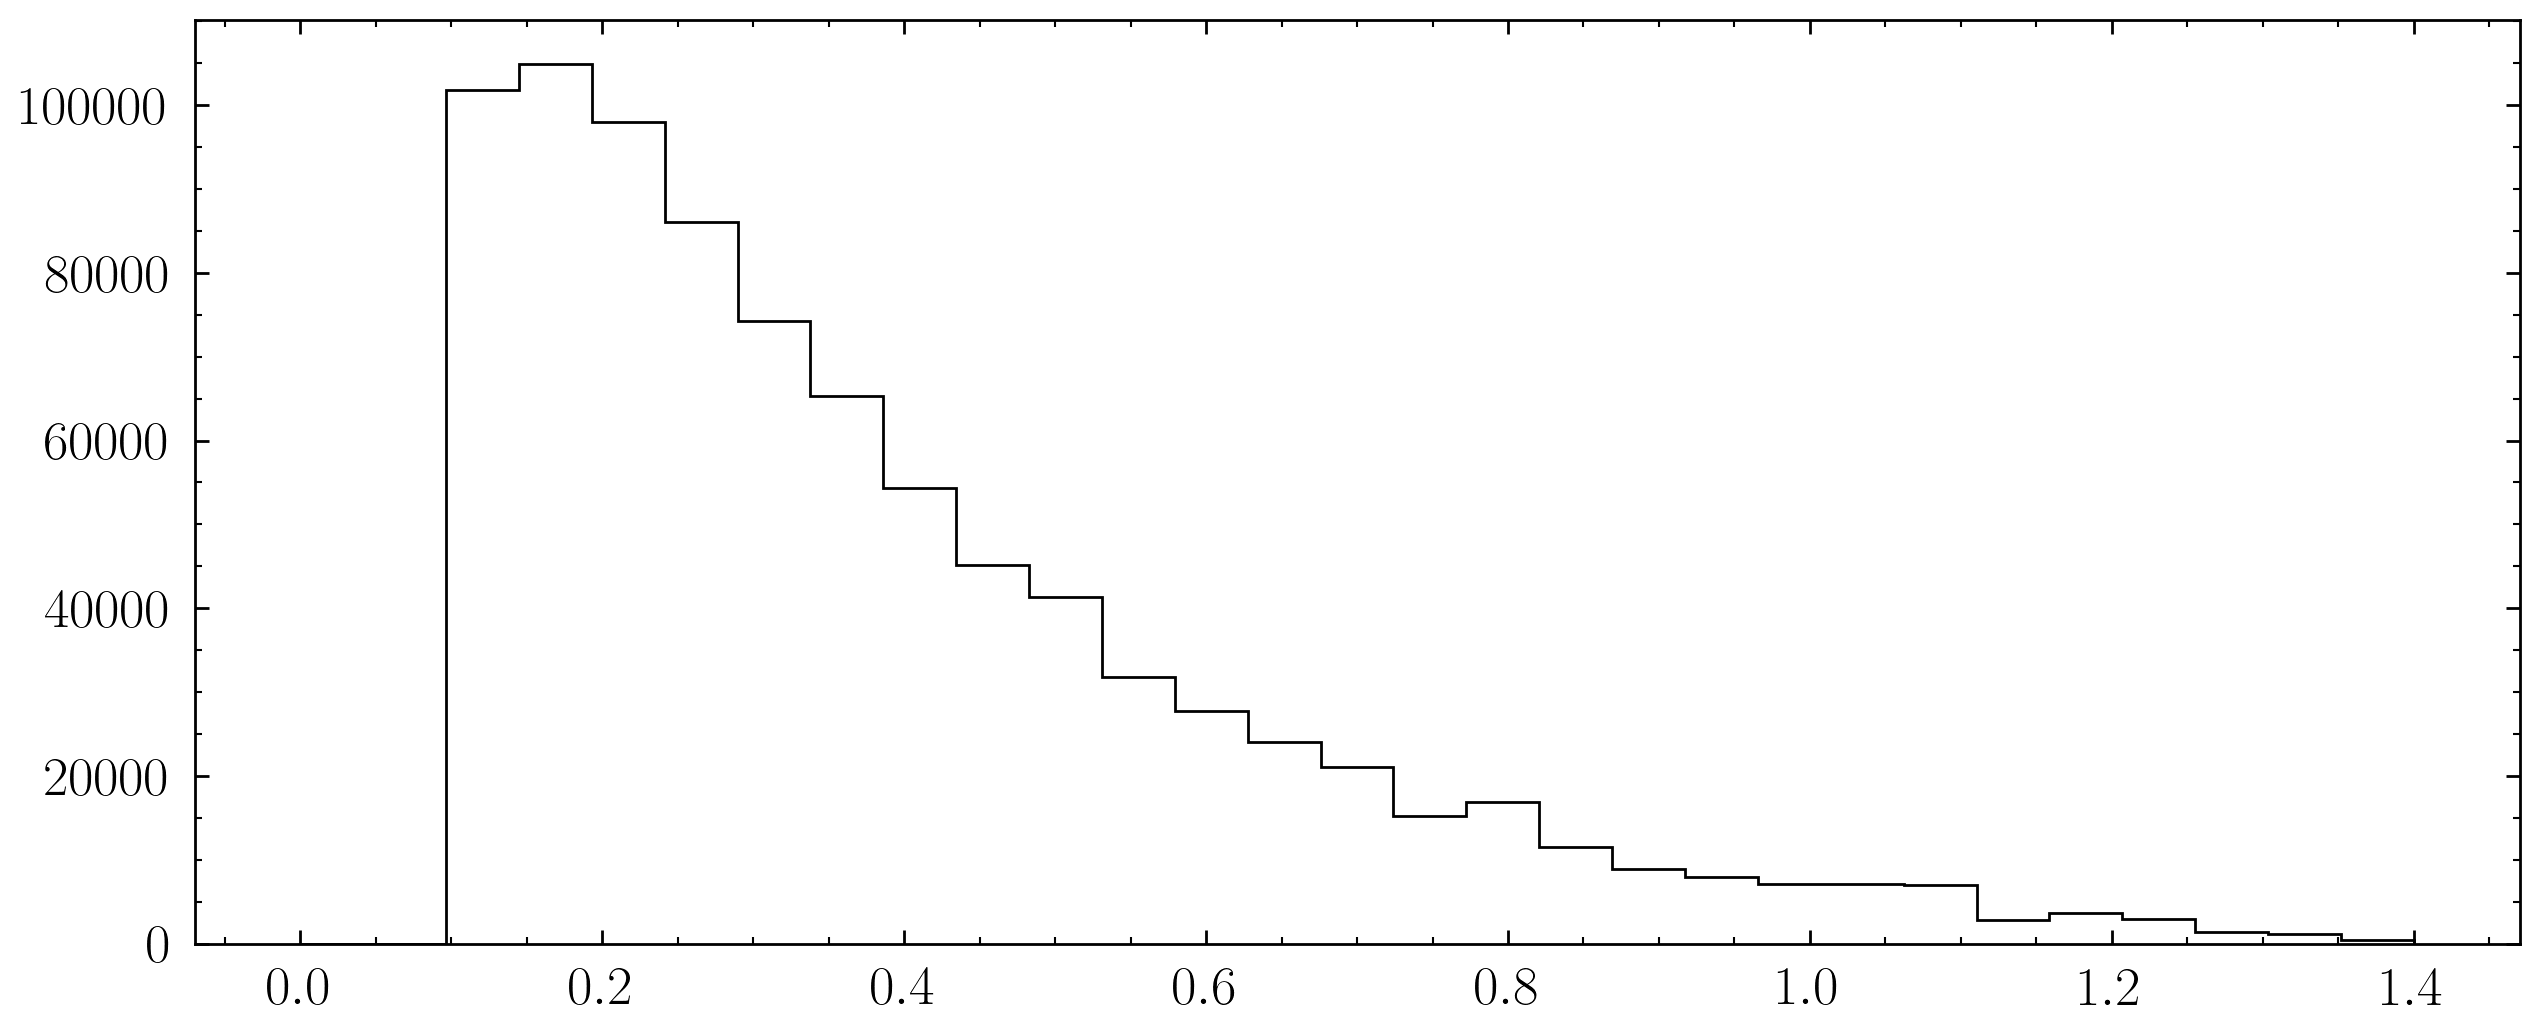

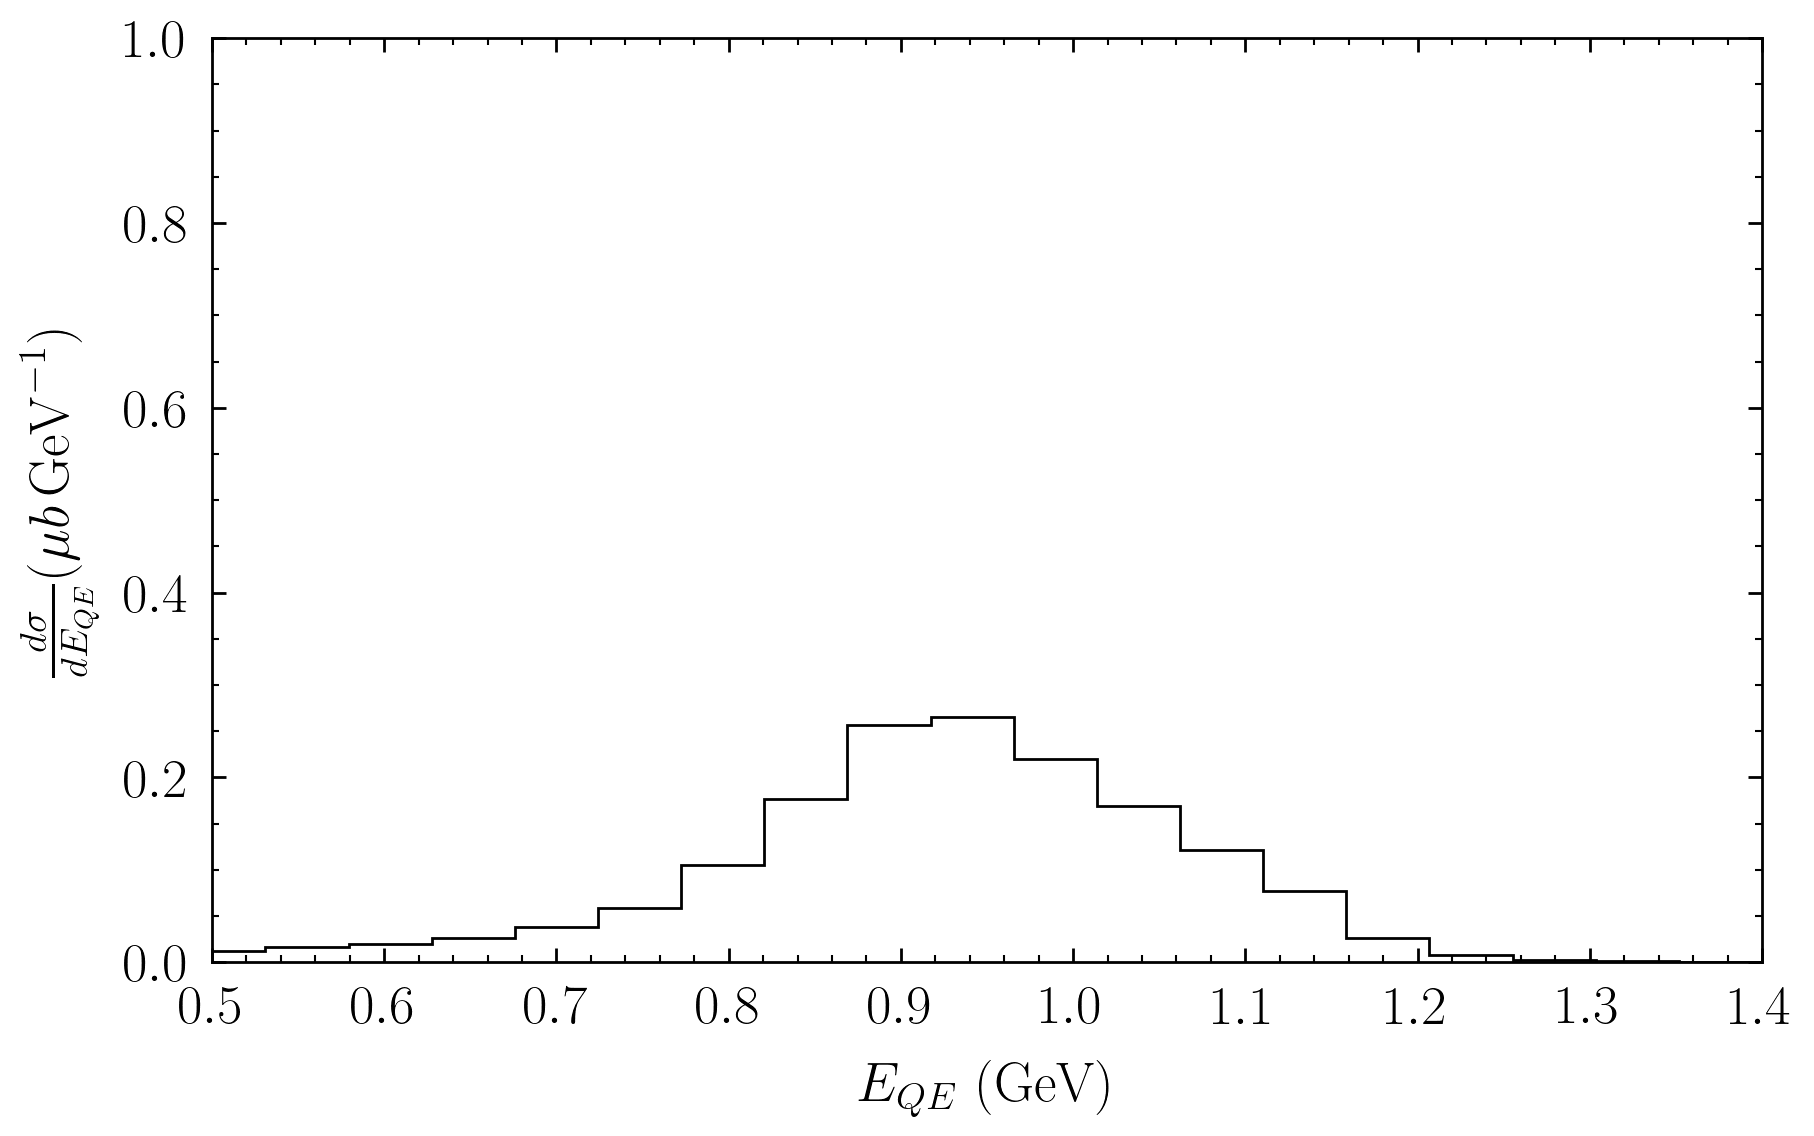

In [42]:
numbins = 30
omegalow = 100
omegahigh = 900

Q2_bins = np.linspace(0,1.4,30)
EQE_bins = np.linspace(0,1.4,30)

dtheta = 1
angle = 37.5
wbins=np.linspace(omegalow,omegahigh,numbins)

#Q2_nuc,leading_mom_an1,subleading_mom_an1,cospp1_2,cospp2_2,Emiss_pp3,Emiss_np3,EQE_nuc = get_double_diff_xsec_wgt('test_FG_1159_q2min_0p1GeV2.out', angle, dtheta, wbins)

fig,ax = plt.subplots(1,1,figsize=(15,6))
Q2_bin_centers = (Q2_bins[:-1] + Q2_bins[1:]) / 2
ax.stairs(Q2_nuc * Q2_bin_centers**2,Q2_bins,color='black',label=r'$\Delta + \pi$')

fig,ax = plt.subplots(1,1,figsize=(10,6))
EQE_bin_centers = (EQE_bins[:-1] + EQE_bins[1:]) / 2
ax.stairs(EQE_nuc*1e-7 ,EQE_bins,color='black',label=r'$\Delta + \pi$')
ax.set_ylim([0,1])
ax.set_xlim([0.5,1.4])
ax.set_xlabel('$E_{QE}$ (GeV)')
ax.set_ylabel(r'$\frac{d\sigma}{dE_{QE}} (\mu b \,\rm{GeV}^{-1})$')

In [17]:
Q2_nuc

array([0.00058937, 0.00058937, 0.00058937, 0.00058937, 0.00058937,
       0.00058937, 0.00058937, 0.00058937, 0.00058937, 0.00058937,
       0.00058937, 0.00058937, 0.00058937, 0.00058937, 0.00058937,
       0.00058937, 0.00058937, 0.00058937, 0.00058937, 0.00058937,
       0.00058937, 0.00058937, 0.00058937, 0.00058937, 0.00058937,
       0.00058937, 0.00058937, 0.00058937, 0.00058937])